In [1]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np

import src.data.loader as loader
import src.indicators.stat_arb as stat_arb
import src.strategies.strategies as strategies
import src.backtest as backtest
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.stattools import adfuller

fetched 252 rows for GLD and 252 rows for GDX


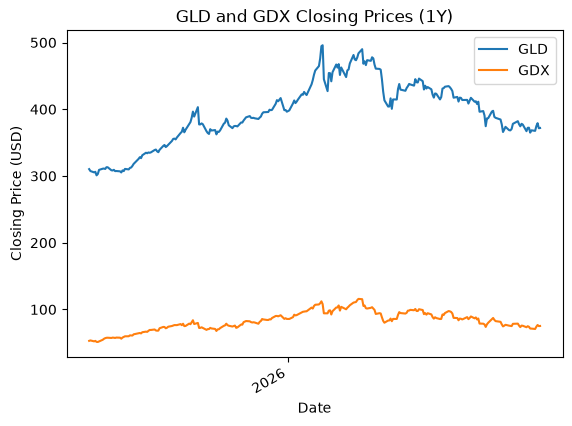

In [2]:
lookback_days = 252

gld_df = loader.get_prices(ticker='GLD', period=f'{lookback_days}d')
gdx_df = loader.get_prices(ticker='GDX', period=f'{lookback_days}d')
print(f"fetched {len(gld_df)} rows for GLD and {len(gdx_df)} rows for GDX")
fig = plt.plot(gld_df.index, gld_df['Close'], label='GLD')
plt.plot(gdx_df.index, gdx_df['Close'], label='GDX')
plt.legend()
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.gcf().autofmt_xdate()
plt.title("GLD and GDX Closing Prices (1Y)")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.show()

beta = 1.4350841640626588, alpha = -4.169142804975588


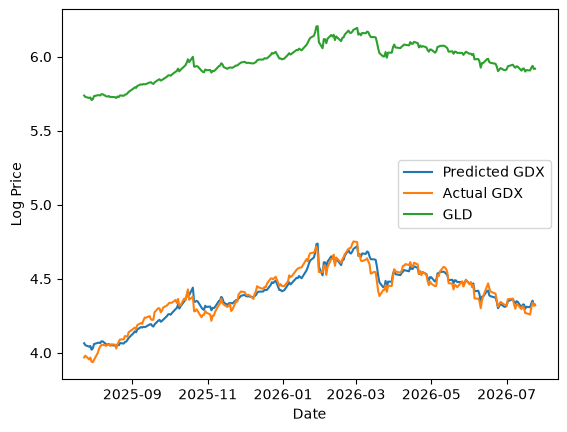

In [3]:
model = LinearRegression()
log_gld = np.log(gld_df['Close'].values.reshape(-1, 1))
log_gdx = np.log(gdx_df['Close'].values.reshape(-1, 1))
# Test with GDX as the dependent variable
model.fit(log_gld, log_gdx)
model.coef_, model.intercept_
predictions = model.predict(log_gld)
print(f"beta = {model.coef_[0][0]}, alpha = {model.intercept_[0]}")
plt.plot(gld_df.index, predictions, label='Predicted GDX')
plt.plot(gld_df.index, log_gdx, label='Actual GDX')
plt.plot(gld_df.index, log_gld, label='GLD')
plt.xlabel("Date")
plt.ylabel("Log Price")
plt.legend()
plt.show()

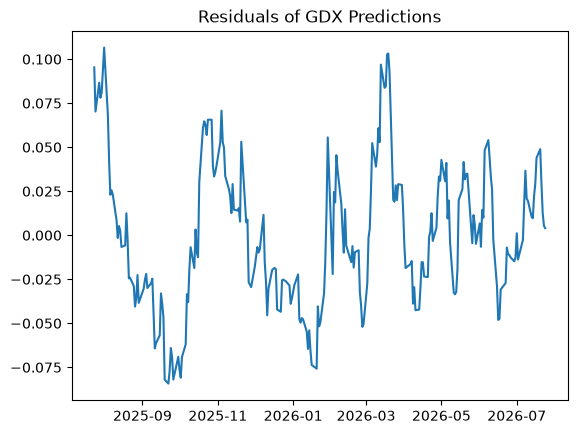

ADF test p-value for residuals: 0.003582023904038018


In [4]:
residuals = predictions - log_gdx
plt.plot(gld_df.index, residuals)
plt.title('Residuals of GDX Predictions')
plt.show()
adfuller_pvalue = adfuller(residuals)[1]
print(f"ADF test p-value for residuals: {adfuller_pvalue}")

### Backtesting the strategy
If we want to use a 252-day lookback period and 21-day training step, we'll need a larger dataset. We look at 3 years.

In [ ]:
gld_three_yr = loader.get_prices(ticker='GLD', period='3y')
gdx_three_yr = loader.get_prices(ticker='GDX', period='3y')
gld_three_yr['log_Close'] = np.log(gld_three_yr['Close'].values.reshape(-1, 1))
gdx_three_yr['log_Close'] = np.log(gdx_three_yr['Close'].values.reshape(-1, 1))
indicators_df = stat_arb.compute_stat_arb_indicators(
    y=gdx_three_yr['log_Close'],
    x=gld_three_yr['log_Close'],
    lookback=252,
    train_step=5)

positions_df = strategies.get_stat_arb_positions(
    indicators_df=indicators_df,
    entry_threshold=1.5,
    exit_threshold=0.1,
    p_value_threshold=0.05)

returns = backtest.compute_strategy_returns_asset_pair(
    y_asset_returns=gdx_three_yr['Close'].pct_change(),
    x_asset_returns=gld_three_yr['Close'].pct_change(),
    positions=positions_df,
    method='simple'
)

,spread_position,y_position,x_position
Date,,,
2026-01-27,1.0,0.347503,-0.652497
2026-01-28,1.0,0.347503,-0.652497
2026-01-29,1.0,0.347503,-0.652497
2026-03-05,1.0,0.360446,-0.639554
2026-03-06,1.0,0.360446,-0.639554
2026-03-09,1.0,0.363505,-0.636495
2026-03-10,1.0,0.363505,-0.636495
2026-03-11,1.0,0.363505,-0.636495
2026-03-12,1.0,0.363505,-0.636495


spread          -0.120391
z_score         -2.079507
beta             1.723367
intercept       -5.900355
coint_p_value    0.082480
Name: 2026-03-17 00:00:00, dtype: float64

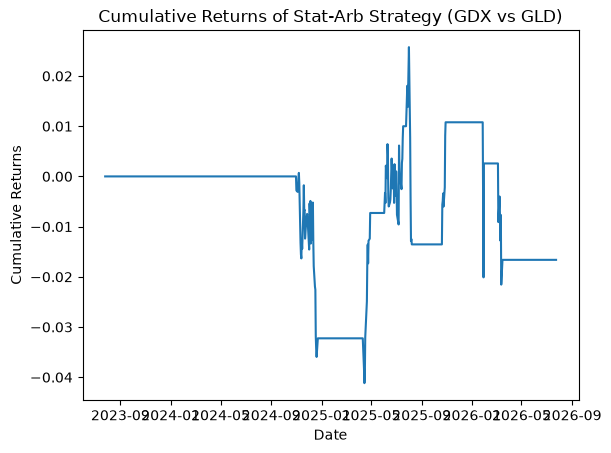

In [21]:
display(positions_df[positions_df['x_position'] != 0].tail(10))
display(indicators_df.loc['2026-03-17'])


plt.plot(returns.index, returns.cumsum())
plt.title("Cumulative Returns of Stat-Arb Strategy (GDX vs GLD)")
plt.xlabel("Date")
plt.ylabel("Cumulative Returns")
plt.show()